# Sensitivity tests on [Ce/Mg]-age trends

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MultipleLocator
from matplotlib.cm import ScalarMappable
from scipy import stats

import paths
from colormaps import paultol
from utils import binned_quantiles, get_bin_centers
from plotting import ONE_COLUMN_WIDTH, TWO_COLUMN_WIDTH, colored_text_legend, truncate_colormap, insert_colorbar_axes

plt.style.use(paths.styles / 'notebook.mplstyle')

In [20]:
full_sample = pd.read_csv(paths.data / 'sample.csv')
full_sample

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,Rg,orbit_flags,fe_h_corr,ce_h_corr,fe_mg_corr,mg_fe_corr,ce_mg_corr,ce_fe_corr,low_alpha,high_alpha
0,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,8.590056,0.0,-0.264773,-0.041934,-0.014932,0.014932,0.207907,0.222839,True,False
1,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,9.153462,0.0,-0.242679,0.026205,0.002179,-0.002179,0.271062,0.268884,True,False
2,54381968,2M00220667+5639444,421558740986710784,421558740986710784,403316795,16025,gaia_dr3_source,31,63050394783222492,4291878364,...,10.254416,0.0,-0.114184,0.175521,-0.022190,0.022190,0.267514,0.289704,True,False
3,54381984,2M00223542+5645497,421560390254274304,421560390254274304,403393131,16025,gaia_dr3_source,31,63050394783223054,4291881586,...,9.035937,0.0,0.060252,0.138125,0.046863,-0.046863,0.124736,0.077873,True,False
4,54382000,2M00220711+5648323,421561489765700224,421561489765700224,403317093,16025,gaia_dr3_source,31,63050394783223394,4291881416,...,14.852359,0.0,-0.184409,-0.040109,0.003998,-0.003998,0.148297,0.144299,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120758,129060797,2M08543799-4600155,5331153616728690432,5331153616728690432,29951519,169169,gaia_dr3_source,31,63050395878304977,5803209549,...,7.758100,0.0,-0.061454,0.194006,0.046142,-0.046142,0.301602,0.255460,True,False
120759,129060805,2M08300191-3959403,5527814224979419776,5527814224979419776,184540591,161717,gaia_dr3_source,31,63050395950376805,5809725641,...,10.770966,0.0,-0.525590,-0.549267,-0.062427,0.062427,-0.086104,-0.023677,True,False
120760,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,4.912325,0.0,-0.365308,-0.171641,-0.013272,0.013272,0.180395,0.193667,True,False
120761,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,9.945469,0.0,-0.178253,0.010530,-0.016042,0.016042,0.172741,0.188783,True,False


## Local abundance trends

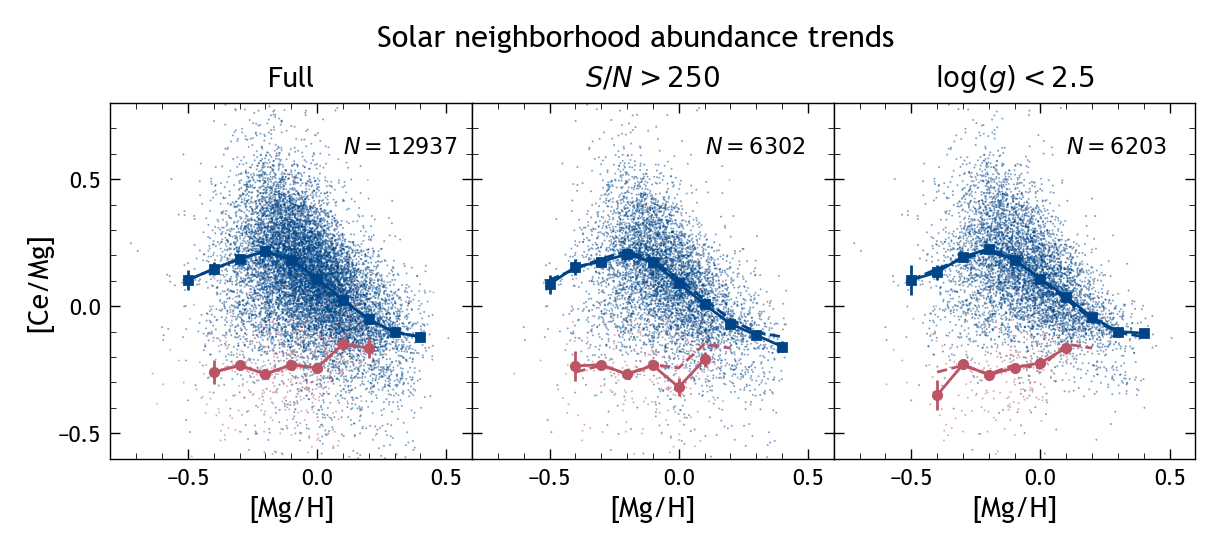

In [ ]:
local_sample = full_sample[(full_sample['Rg'] >= 7) & (full_sample['Rg'] < 9) & (full_sample['z_max'] < 0.5)]
local_highsn = local_sample[local_sample['snr'] > 250]
local_lowlogg = local_sample[local_sample['logg'] < 2.5]
local_rc = local_sample[(local_sample['logg'] < 2.5) & (local_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
local_high_ia_medians = binned_quantiles(
    local_sample[local_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
local_low_ia_medians = binned_quantiles(
    local_sample[local_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([local_sample, local_highsn, local_lowlogg]):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia['ce_mg_corr'],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia['ce_mg_corr'],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *local_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *local_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.6, 0.8))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Solar neighborhood abundance trends', y=1.05)
plt.show()

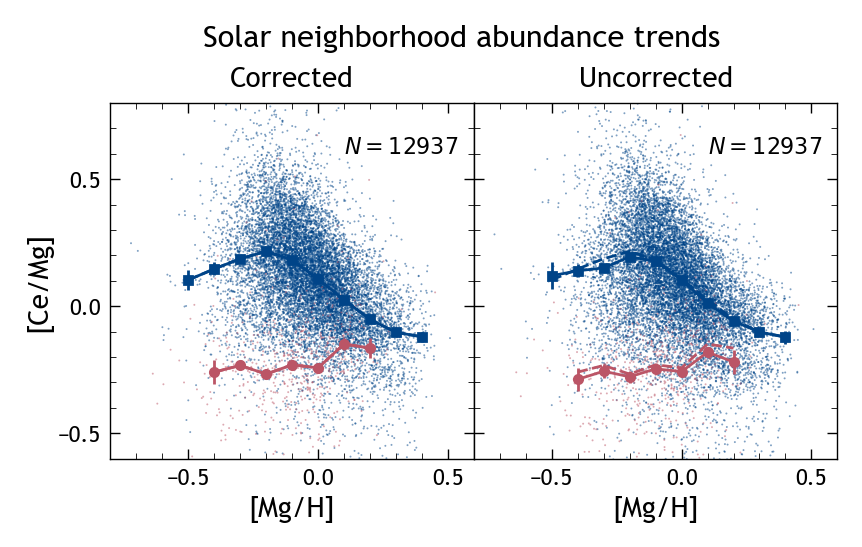

In [ ]:
mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
local_high_ia_medians = binned_quantiles(
    local_sample[local_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
local_low_ia_medians = binned_quantiles(
    local_sample[local_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.67*TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Corrected', 'Uncorrected']
df = local_sample
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia[col],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia[col],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *local_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *local_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.6, 0.8))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Solar neighborhood abundance trends', y=1.05)
plt.show()

## Inner galaxy abundance trends

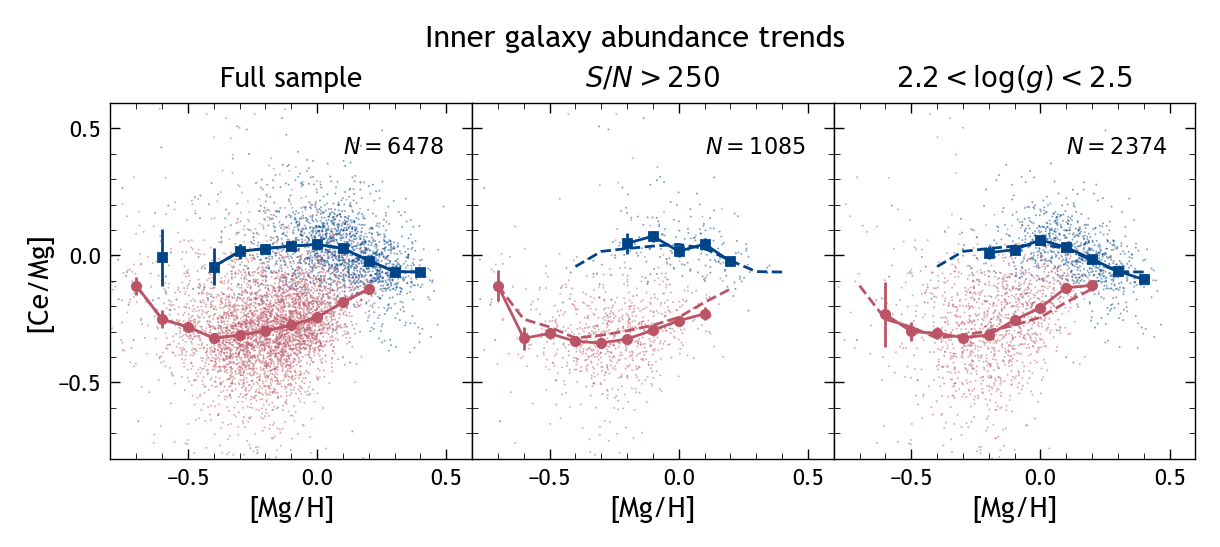

In [ ]:
inner_sample = full_sample[(full_sample['Rg'] >= 3) & (full_sample['Rg'] < 5) & (full_sample['z_max'] < 2)]
inner_highsn = inner_sample[inner_sample['snr'] > 250]
inner_lowlogg = inner_sample[inner_sample['logg'] < 2.5]
inner_rc = inner_sample[(inner_sample['logg'] < 2.5) & (inner_sample['logg'] > 2.2)]

mg_bin_edges = np.arange(-0.75, 0.76, 0.1)
inner_high_ia_medians = binned_quantiles(
    inner_sample[inner_sample['high_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)
inner_low_ia_medians = binned_quantiles(
    inner_sample[inner_sample['low_ia']], 'ce_mg_corr', 'mg_h', 
    q=0.5, bin_edges=mg_bin_edges, min_count=10
)

low_ia_color = paultol.highcontrast.colors[2]
high_ia_color = paultol.highcontrast.colors[0]

fig, axs = plt.subplots(
    1, 3, 
    figsize=(TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Full sample', r'$S/N > 250$', r'$2.2 < \log(g) < 2.5$']
for i, df in enumerate([inner_sample, inner_highsn, inner_rc]):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia['ce_mg_corr'],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia['ce_mg_corr'],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, 'ce_mg_corr', 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *inner_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *inner_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.8, 0.6))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Inner galaxy abundance trends', y=1.05)
plt.show()

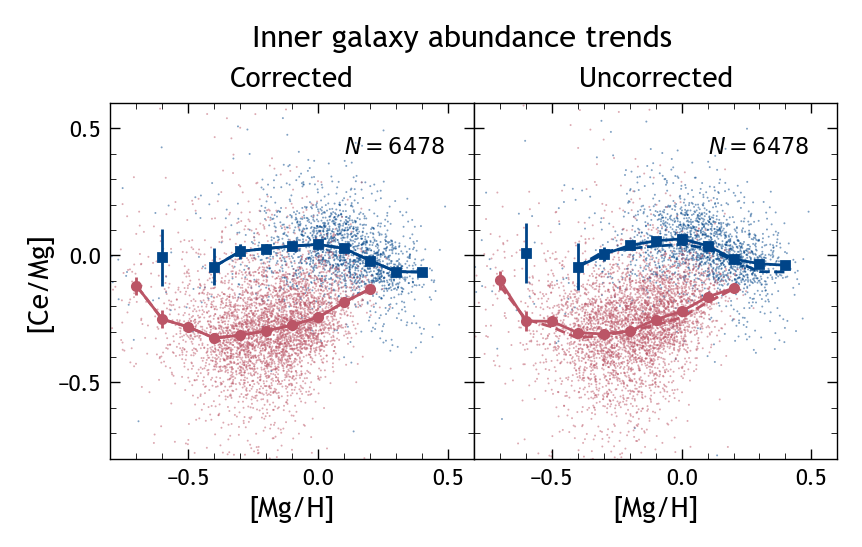

In [ ]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.67*TWO_COLUMN_WIDTH, 0.33*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
labels = ['Corrected', 'Uncorrected']
df = inner_sample
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot individual stars
    df_high_ia = df[df['high_ia']]
    axs[i].scatter(
        df_high_ia['mg_h'], df_high_ia[col],
        c=high_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    df_low_ia = df[df['low_ia']]
    axs[i].scatter(
        df_low_ia['mg_h'], df_low_ia[col],
        c=low_ia_color, s=2, marker='.', edgecolors='none', rasterized=True, alpha=0.5
    )
    # Plot median trends
    axs[i].errorbar(
        *binned_quantiles(
            df_high_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10, 
            est_errors=True
        ), 
        fmt='s-', markersize=3, color=high_ia_color, capsize=0
    )
    axs[i].errorbar(
        *binned_quantiles(
            df_low_ia, col, 'mg_h', 
            q=0.5, bin_edges=mg_bin_edges, min_count=10,
            est_errors=True
        ), 
        fmt='o-', markersize=3, color=low_ia_color, capsize=0
    )
    # Compare against full sample
    axs[i].plot(
        *inner_high_ia_medians, 
        linestyle='--', color=high_ia_color, label='High-Ia',
    )
    axs[i].plot(
        *inner_low_ia_medians, 
        linestyle='--', color=low_ia_color, label='Low-Ia',
    )
    # Sample size
    axs[i].text(0.1, 0.4, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('[Mg/H]')
axs[0].set_xlim((-0.8, 0.6))
axs[0].set_ylim((-0.8, 0.6))
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
fig.suptitle('Inner galaxy abundance trends', y=1.05)
plt.show()

## Local metallicity dependence

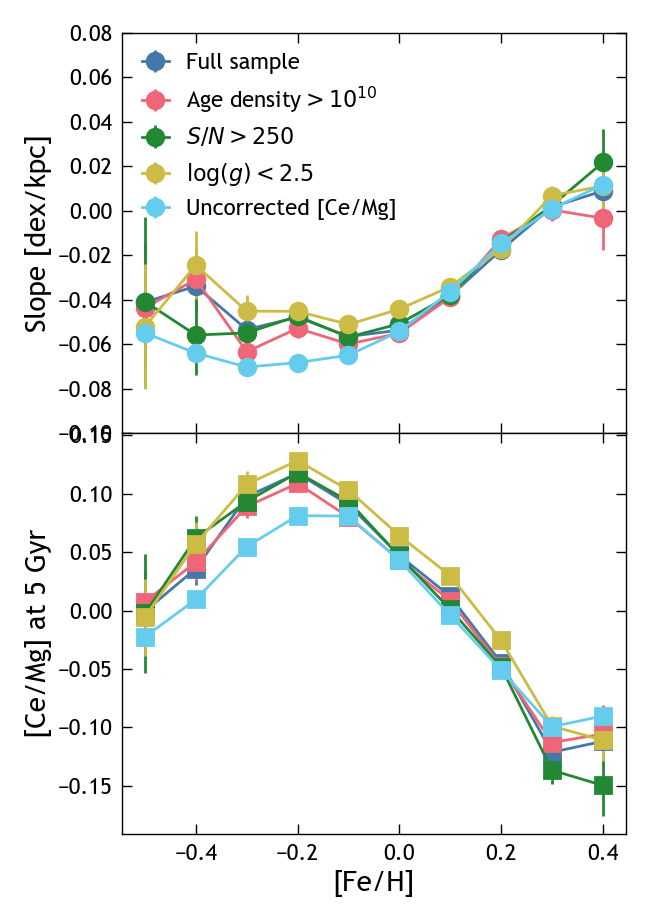

In [ ]:
local_ages = local_sample[(local_sample['good_age'])]
local_betterage = local_ages[local_ages['training_density'] > 1e10]
local_highsn_age = local_ages[local_ages['snr'] > 250]
local_lowlogg_age = local_ages[local_ages['logg'] < 2.5]
local_rc_age = local_ages[(local_ages['logg'] < 2.5) & (local_ages['logg'] > 2.2)]

plt.rcParams['axes.prop_cycle'] = plt.cycler('color', paultol.bright.colors)
fig, axs = plt.subplots(
    2, 
    figsize=(ONE_COLUMN_WIDTH, 1.6*ONE_COLUMN_WIDTH), 
    sharex=True,
    gridspec_kw={'hspace': 0}
)

met_bins = np.arange(-0.55, 0.46, 0.1)
age_fit_range = (1, 8)
met_col = 'fe_h'
age_delta = 5 # Gyr

ycols = ['ce_mg_corr'] * 4 + ['ce_mg']
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$', 'Uncorrected [Ce/Mg]']
for i, df in enumerate([local_ages, local_betterage, local_highsn_age, local_lowlogg_age, full_sample]):
    df_high_ia = df[df['high_ia']]
    # Bin by metallicity and fit linear trend to stars within good age range
    fits = []
    age_arr = np.arange(0, 12.1, 0.1)
    for j in range(len(met_bins)-1):
        met_lim = met_bins[j:j+2]
        met_center = np.mean(met_lim) # mean metallicity of bin
        subset = df_high_ia[
            (df_high_ia[met_col] >= met_lim[0]) & 
            (df_high_ia[met_col] < met_lim[1]) &
            (df_high_ia['age'] >= age_fit_range[0]) &
            (df_high_ia['age'] < age_fit_range[1])
        ]
        # Fit linear age trend
        regress = stats.linregress(subset['age'] - age_delta, subset[ycols[i]])
        fits.append(regress)
    # Plot slopes
    slopes = [f.slope for f in fits]
    slope_errs = [f.stderr for f in fits]
    met_bin_centers = get_bin_centers(met_bins)
    axs[0].errorbar(
        met_bin_centers, slopes, yerr=slope_errs, 
        label=labels[i],
        marker='o', linestyle='-', capsize=0
    )
    # Plot intercepts
    intercepts = [f.intercept for f in fits]
    intercept_errs = [f.intercept_stderr for f in fits]
    axs[1].errorbar(
        met_bin_centers, intercepts, yerr=intercept_errs, 
        label=labels[i],
        marker='s', linestyle='-', capsize=0
    )

axs[0].legend()
axs[1].set_xlabel('[Fe/H]')
axs[0].set_ylabel('Slope [dex/kpc]')
axs[1].set_ylabel('[Ce/Mg] at %s Gyr' % age_delta)
axs[0].set_ylim((-0.1, 0.08))
plt.show()

## Global age trends

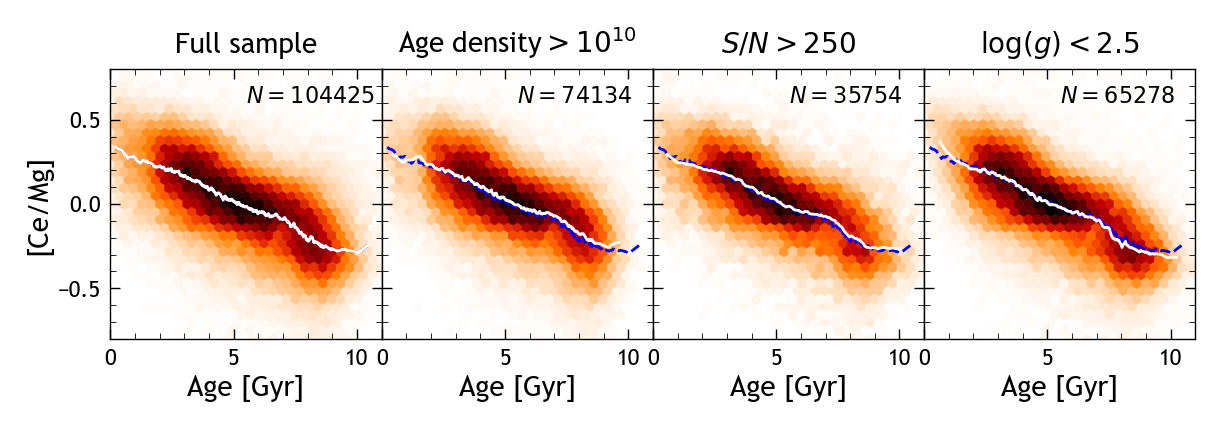

In [26]:
full_ages = full_sample[full_sample['good_age']]
better_ages = full_ages[full_ages['training_density'] > 1e10]
highsn_ages = full_ages[full_ages['snr'] > 250]
lowlogg_ages = full_ages[full_ages['logg'] < 2.5]
rc_ages = full_ages[(full_ages['logg'] < 2.5) & (full_ages['logg'] > 2.2)]

# Compute full sample rolling median trend
full_sorted_ages = full_ages.sort_values('age')[['age', 'ce_mg_corr']]
full_rolling_medians = full_sorted_ages.rolling(
    1000, min_periods=1000, step=250, on='age', center=True
).median()

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.8, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([full_ages, better_ages, highsn_ages, lowlogg_ages]):
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        cmap='gist_heat_r',
        gridsize=30,
        linewidths=0.2,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        vmin=0
    )
    # Full sample rolling median for comparison
    axs[i].plot(full_rolling_medians['age'], full_rolling_medians['ce_mg_corr'], 'b--')
    # Rolling median
    sorted_ages = df.sort_values('age')[['age', 'ce_mg_corr']]
    rolling_medians = sorted_ages.rolling(
        1000, min_periods=1000, step=250, on='age', center=True
    ).median()
    axs[i].plot(rolling_medians['age'], rolling_medians['ce_mg_corr'], 'w-')
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
plt.show()

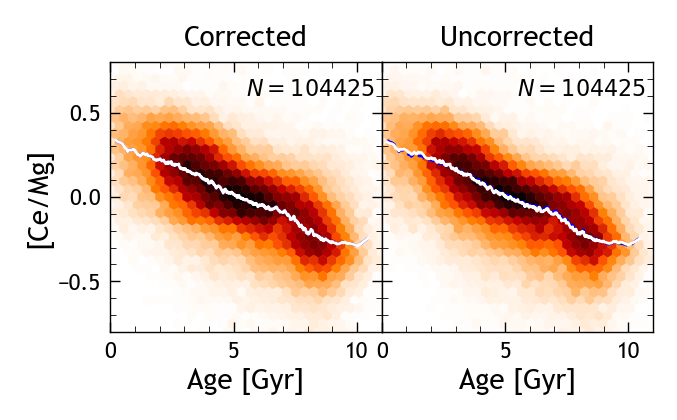

In [27]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.5*TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.8, 0.8)
labels = ['Corrected', 'Uncorrected']
df = full_ages
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    pcm = axs[i].hexbin(
        df['age'], df[col],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        cmap='gist_heat_r',
        gridsize=30,
        linewidths=0.2,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
        vmin=0
    )
    # Full sample rolling median for comparison
    axs[i].plot(full_rolling_medians['age'], full_rolling_medians['ce_mg_corr'], 'b--')
    # Rolling median
    sorted_ages = df.sort_values('age')[['age', col]]
    rolling_medians = sorted_ages.rolling(
        1000, min_periods=1000, step=250, on='age', center=True
    ).median()
    axs[i].plot(rolling_medians['age'], rolling_medians[col], 'w-')
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
plt.show()

## Global radial dependence

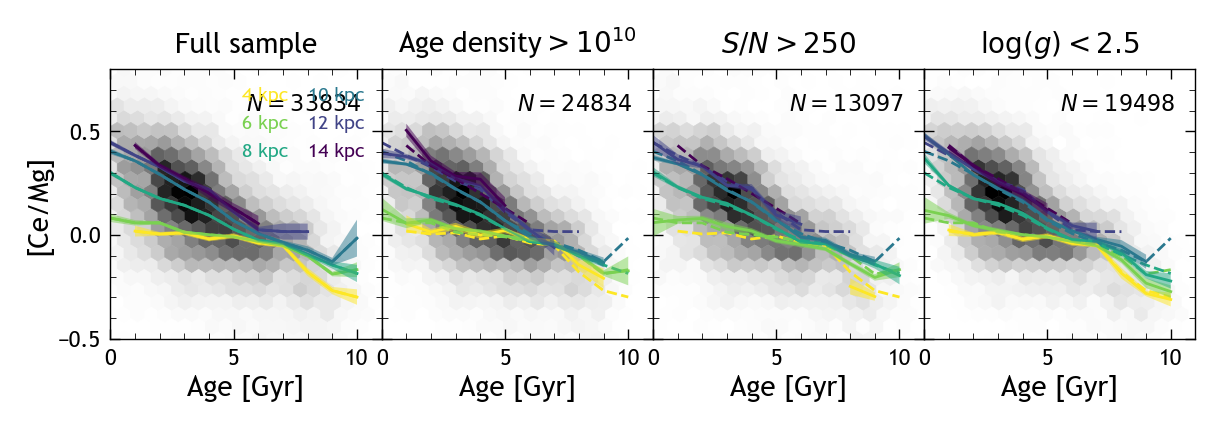

In [28]:
lowz_ages = full_sample[(full_sample['good_age']) & (full_sample['z_max'] < 0.5)]
better_ages = lowz_ages[lowz_ages['training_density'] > 1e10]
highsn_ages = lowz_ages[lowz_ages['snr'] > 250]
lowlogg_ages = lowz_ages[lowz_ages['logg'] < 2.5]
rc_ages = lowz_ages[(lowz_ages['logg'] < 2.5) & (lowz_ages['logg'] > 2.2)]

radius_bin_edges = np.arange(3, 15.1, 2)
age_bin_edges = np.arange(-0.5, 11.6, 1)
radial_cmap = plt.get_cmap('viridis_r')
norm = BoundaryNorm(radius_bin_edges, radial_cmap.N)

fig, axs = plt.subplots(
    1, 4, 
    figsize=(TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
labels = ['Full sample', r'Age density$>10^{10}$', r'$S/N > 250$', r'$\log(g) < 2.5$']
for i, df in enumerate([lowz_ages, better_ages, highsn_ages, lowlogg_ages]):
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df['ce_mg_corr'],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=20,
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
colored_text_legend(axs[0], ncols=2, fontsize=7, columnspacing=1)
plt.show()

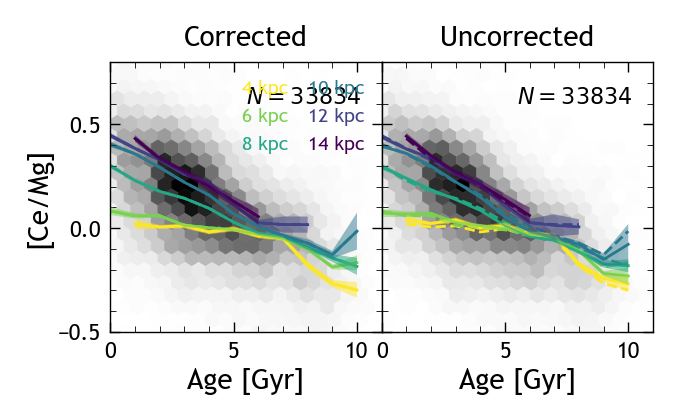

In [29]:
fig, axs = plt.subplots(
    1, 2, 
    figsize=(0.5*TWO_COLUMN_WIDTH, 0.25*TWO_COLUMN_WIDTH), 
    sharex=True, sharey=True, 
    gridspec_kw={'wspace': 0}
)
xlim = (0, 11)
ylim = (-0.5, 0.8)
labels = ['Corrected', 'Uncorrected']
df = lowz_ages
for i, col in enumerate(['ce_mg_corr', 'ce_mg']):
    # Plot all stars
    pcm = axs[i].hexbin(
        df['age'], df[col],
        C=np.ones(df.shape[0]),
        reduce_C_function=np.sum,
        gridsize=20,
        cmap='binary',
        linewidths=0.2,
        mincnt=0,
        extent=[xlim[0], xlim[1], ylim[0], ylim[1]]
    )
    # Plot median age trends binned by radius
    for j in range(len(radius_bin_edges)-1):
        radius_bin = radius_bin_edges[j:j+2]
        mean_radius = np.mean(radius_bin)
        df_subset = df[
            (df['Rg'] >= radius_bin[0]) &
            (df['Rg'] < radius_bin[1])
        ]
        age_medians = binned_quantiles(
            df_subset, col, 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *age_medians[:-1], '-', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
            label=f'{int(mean_radius)} kpc'
        )
        axs[i].fill_between(
            age_medians[0],
            age_medians[1]+age_medians[2],
            age_medians[1]-age_medians[2],
            color=radial_cmap(norm(mean_radius)),
            alpha=0.5, edgecolor='none', zorder=2
        )
        # Compare vs median trends in full sample
        full_subset = lowz_ages[
            (lowz_ages['Rg'] >= radius_bin[0]) &
            (lowz_ages['Rg'] < radius_bin[1])
        ]
        full_age_medians = binned_quantiles(
            full_subset, 'ce_mg_corr', 'age',
            q=0.5, bin_edges=age_bin_edges, min_count=20, est_errors=True
        )
        axs[i].plot(
            *full_age_medians[:-1], '--', 
            color=radial_cmap(norm(mean_radius)), zorder=1,
        )
    # Sample size
    axs[i].text(5.5, 0.6, r'$N=%s$' % df.shape[0])
    axs[i].set_title(labels[i])

axs[0].set_ylabel('[Ce/Mg]')
for ax in axs:
    ax.set_xlabel('Age [Gyr]')
axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)
axs[0].xaxis.set_major_locator(MultipleLocator(5))
axs[0].xaxis.set_minor_locator(MultipleLocator(1))
axs[0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0].yaxis.set_minor_locator(MultipleLocator(0.1))
colored_text_legend(axs[0], ncols=2, fontsize=7, columnspacing=1)
plt.show()

## log(g) abundance corrections

Solar neighborhood stars (both on and off the midplane) seem to benefit from the log(g) corrections. On the other hand, luminous giants in the inner and outer galaxy actually look slightly worse with the corrections than without.

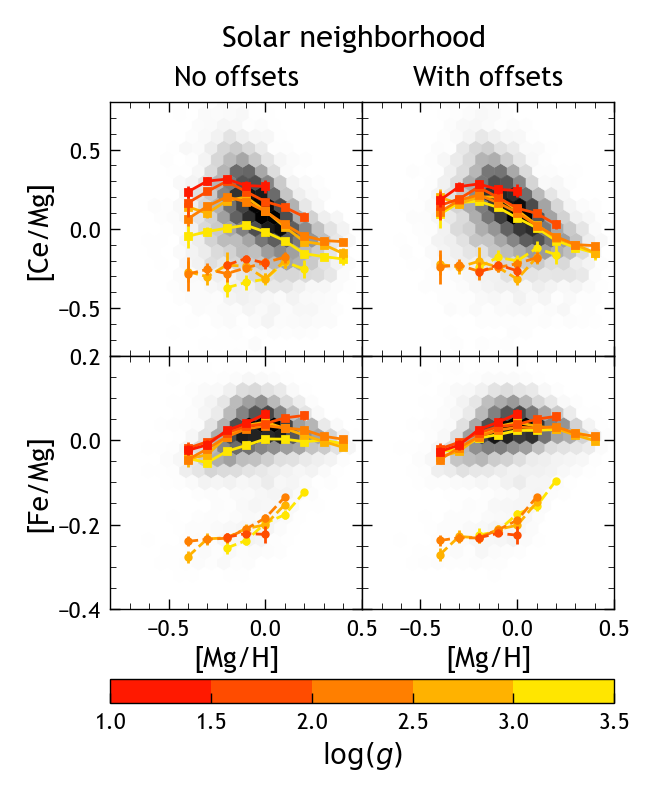

In [ ]:
# Initialize grid of log(g), [Mg/H] values
MgH_bin_edges = np.round(np.linspace(-0.75, 0.45, 13, endpoint=True), 2)
MgH_bin_centers = get_bin_centers(MgH_bin_edges)
logg_bin_edges = np.linspace(0, 3.5, 8, endpoint=True)
logg_bin_centers = get_bin_centers(logg_bin_edges)
AXES_LIM = {
    'mg_h': (-0.8, 0.5),
    'ce_mg': (-0.8, 0.8),
    'fe_mg': (-0.4, 0.2)
}

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        local_sample['mg_h'], local_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = local_sample[
            (local_sample['logg'] > logg_lim[0]) & 
            (local_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Solar neighborhood')
plt.show()

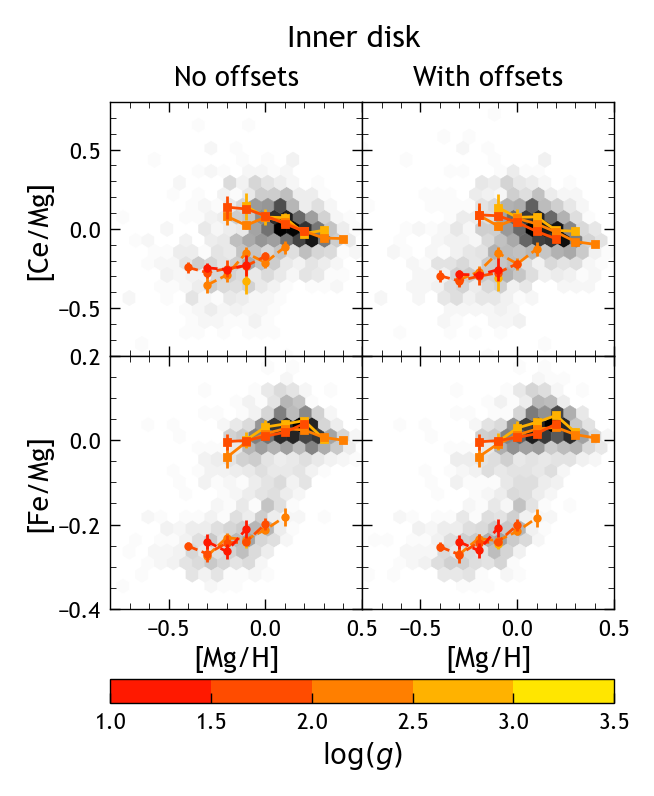

In [ ]:
inner_sample = full_sample[(full_sample['Rg'] >= 3) & (full_sample['Rg'] < 5) & (full_sample['z_max'] < 0.5)]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        inner_sample['mg_h'], inner_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = inner_sample[
            (inner_sample['logg'] > logg_lim[0]) & 
            (inner_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Inner disk')
plt.show()

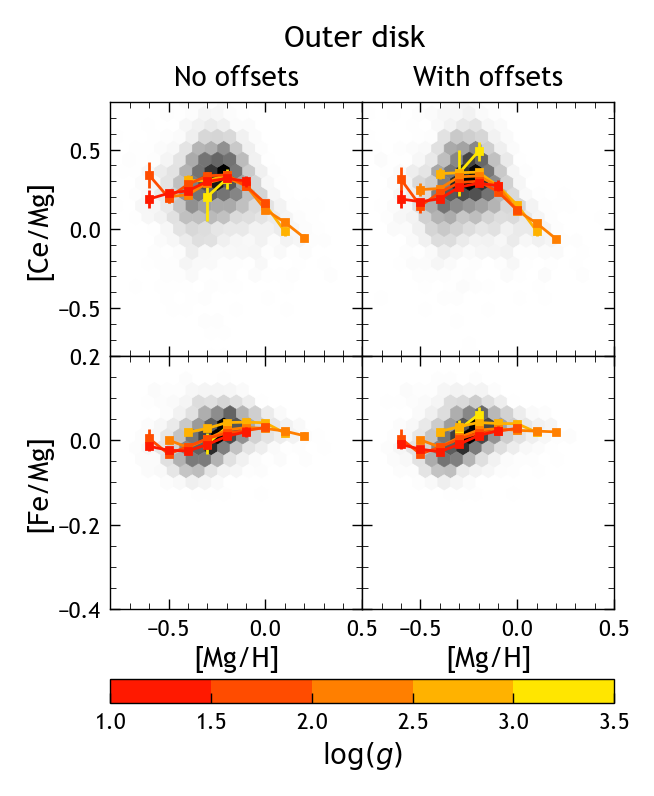

In [ ]:
outer_sample = full_sample[(full_sample['Rg'] >= 11) & (full_sample['Rg'] < 13) & (full_sample['z_max'] < 0.5)]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        outer_sample['mg_h'], outer_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = outer_sample[
            (outer_sample['logg'] > logg_lim[0]) & 
            (outer_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('Outer disk')
plt.show()

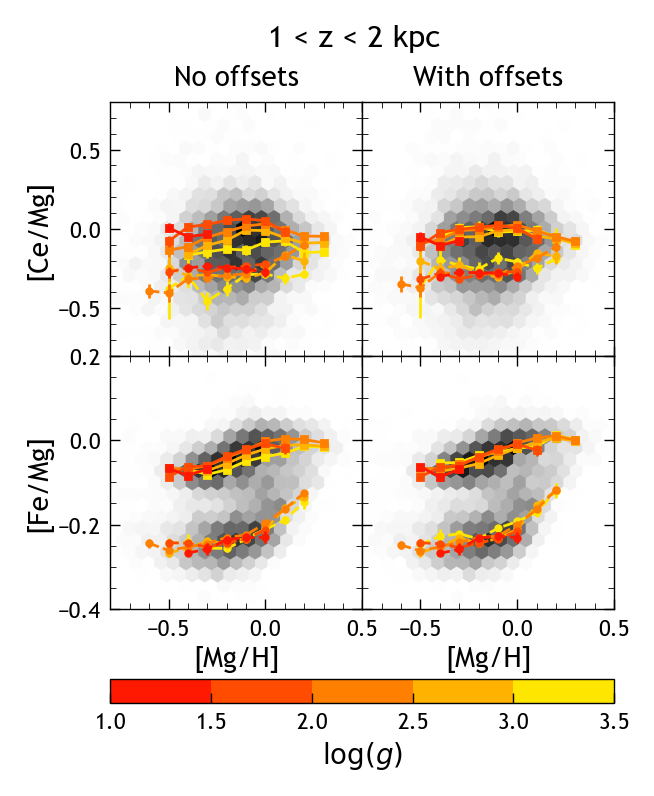

In [ ]:
highlat_sample = full_sample[
    (full_sample['Rg'] >= 7) & 
    (full_sample['Rg'] < 9) & 
    (full_sample['z_max'] > 1) &
    (full_sample['z_max'] < 2)
]

# Plot
fig, axs = plt.subplots(
    2, 2, 
    sharex=True, sharey='row',
    figsize=(ONE_COLUMN_WIDTH, 1.2 * ONE_COLUMN_WIDTH),
    gridspec_kw={'hspace': 0, 'wspace': 0}
)
cmap = truncate_colormap(plt.get_cmap('autumn'), minval=0.1, maxval=0.9)
norm = BoundaryNorm(logg_bin_edges[2:], cmap.N)
hexbin_kw = dict(gridsize=20, linewidths=0.2, cmap='binary')
ms = 2
for i, ycol in enumerate(['ce_mg', 'ce_mg_corr', 'fe_mg', 'fe_mg_corr']):
    ax = axs.flatten()[i]
    # 2D hexbin of all stars
    ax.hexbin(
        highlat_sample['mg_h'], highlat_sample[ycol], 
        extent=[*AXES_LIM['mg_h'], *AXES_LIM[ycol.replace('_corr', '')]], 
        **hexbin_kw
    )
    # Plot median trends binned by log(g)
    # Ignore log(g) < 1 as that is outside the sample cut
    for j in range(2, logg_bin_centers.shape[0]):
        logg_lim = logg_bin_edges[j:j+2]
        logg_center = np.sum(logg_bin_edges[j:j+2])/2
        logg_subset = highlat_sample[
            (highlat_sample['logg'] > logg_lim[0]) & 
            (highlat_sample['logg'] < logg_lim[1])
        ]
        # High-alpha median trends, binned by [Mg/H]
        low_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['low_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *low_ia_uncorr_med, 
            fmt='o--', markersize=ms, 
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
        # Low-alpha median trends, binned by [Mg/H]
        high_ia_uncorr_med = binned_quantiles(
            logg_subset[logg_subset['high_ia']], ycol, 'mg_h', 
            q=0.5, bin_edges=MgH_bin_edges, min_count=10, est_errors=True
        )
        ax.errorbar(
            *high_ia_uncorr_med, 
            fmt='s-', markersize=ms,
            capsize=0,
            color=cmap(norm(logg_center)),
            zorder=10-j
        )
# Add colorbar
cax = insert_colorbar_axes(
    fig, 
    pad=0.06, width=0.03, 
    orientation='horizontal'
)
fig.colorbar(
    ScalarMappable(norm, cmap), 
    cax=cax, 
    label=r'$\log(g)$', 
    orientation='horizontal'
)
cax.yaxis.set_inverted(True)
# Plot labels
axs[0,0].set_title('No offsets')
axs[0,1].set_title('With offsets')
axs[0,0].set_ylabel('[Ce/Mg]')
axs[1,0].set_ylabel('[Fe/Mg]')
axs[1,0].set_xlabel('[Mg/H]')
axs[1,1].set_xlabel('[Mg/H]')
# Axes limits
axs[0,0].set_xlim(AXES_LIM['mg_h'])
axs[0,0].set_ylim(AXES_LIM['ce_mg'])
axs[1,0].set_ylim(AXES_LIM['fe_mg'])
# Axes tickers
axs[0,0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].xaxis.set_minor_locator(MultipleLocator(0.1))
axs[0,0].yaxis.set_major_locator(MultipleLocator(0.5))
axs[0,0].yaxis.set_minor_locator(MultipleLocator(0.1))
axs[1,0].yaxis.set_major_locator(MultipleLocator(0.2))
axs[1,0].yaxis.set_minor_locator(MultipleLocator(0.05))
fig.suptitle('1 < z < 2 kpc')
plt.show()